In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import random
import warnings
# from func_curvefit import *
import os
path_to_add = os.path.abspath('../')
sys.path.append(path_to_add)
from func_fix_curvefit_params import *
from func_curvefit import *

In [2]:
root_folder = '../../data/playfight_data/'

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

s=16 # CHANGE FONTSIZE HERE
plt.rc('font', size=s) #controls default text size
plt.rc('axes', titlesize=s) #fontsize of the title
plt.rc('axes', labelsize=s) #fontsize of the x and y labels
plt.rc('xtick', labelsize=14) #fontsize of the x tick labels
plt.rc('ytick', labelsize=14) #fontsize of the y tick labels
plt.rc('legend', fontsize=s) #fontsize of the legend

color_plots = 'tab:red' # or tab:red

In [4]:
batch_name1 = 'final_data_triallevel_sorted_ses1'
batch_name2 = 'final_data_triallevel_sorted_ses2'
curvefit_name1 = 'curve_fit_aggressiveness_ses1_linear/all_params_1k_fight_linear' #'curve_trait_apr_ses1'
curvefit_name2 = 'curve_fit_aggressiveness_ses2_linear/all_params_1k_fight_linear' #'curve_trait_apr_ses2'

In [5]:
# session 1 rating
df_group_test = pd.read_csv(f'{root_folder}/{batch_name1}.csv',index_col=[0])
df_group_test = df_group_test.loc[:, df_group_test.columns != 'stim_file']
df_group_test = df_group_test.groupby(['subID','chargeSpeeds']).agg(['mean', 'std']).reset_index()
# session 1 curvefit
df_curve_test = pd.read_csv(f'{root_folder}{curvefit_name1}.csv')

In [6]:
# session 2 rating
df_group_retest = pd.read_csv(f'{root_folder}/{batch_name2}.csv',index_col=[0])
df_group_retest = df_group_retest.loc[:, df_group_retest.columns != 'stim_file']
df_group_retest = df_group_retest.groupby(['subID','chargeSpeeds']).agg(['mean', 'std']).reset_index()
# session 2 curvefit
df_curve_retest = pd.read_csv(f'{root_folder}{curvefit_name2}.csv')

In [7]:
sub_title = [201, 202, 203, 204, 205, 206, 207] #[2001, 2002, 2003, 2004, 2005, 2006, 2007]

### plotting

In [8]:
# selecting participants (hand picked)
subID_select = [26003, 26005, 26329, 26009, 26192, 26113, 26168] #168
df_rating_test_select = df_group_test[df_group_test['subID'].isin(subID_select)]
df_curve_test_select = df_curve_test[df_curve_test['subID'].isin(subID_select)]
df_rating_retest_select = df_group_retest[df_group_retest['subID'].isin(subID_select)]
df_curve_retest_select = df_curve_retest[df_curve_retest['subID'].isin(subID_select)]

In [9]:
df_group_test.shape, df_group_retest.shape

((2233, 12), (1883, 12))

In [10]:
df_curve_test = add_new_params(df_curve_test)
df_curve_test = df_curve_test.loc[df_curve_test['range']>0,:]
df_curve_test

,subID,r_squared,nrmse,aic,obj_center,slope,intercept,bias_xmin,bias_xmax,bias_lower,bias_upper,flipped,range,bias
0,26000.0,0.940328,0.089873,-35.484797,0.709516,0.704565,0.000100,0.000100,0.295335,0.0,0.0,False,0.704565,0.000338
1,26001.0,0.823224,0.147384,-35.444795,0.594001,0.386857,0.270206,0.270206,0.342937,0.0,0.0,False,0.386857,0.440691
2,26002.0,0.799844,0.174349,-27.675491,0.550578,0.624214,0.156321,0.156321,0.219464,0.0,0.0,False,0.624214,0.415986
3,26003.0,0.915302,0.111619,-26.697277,0.499900,1.000000,0.000100,0.000100,0.000000,0.0,0.0,False,0.999900,1.000000
4,26004.0,0.972040,0.051894,-43.866039,0.526637,0.579214,0.194964,0.194964,0.225821,0.0,0.0,False,0.579214,0.463334
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
314,26344.0,0.849478,0.155297,-23.720998,0.606647,0.824037,0.000100,0.000100,0.175863,0.0,0.0,False,0.824037,0.000568
315,26345.0,0.803122,0.179504,-20.200661,0.391841,1.000000,0.108159,0.108159,0.000000,0.0,0.0,False,0.891841,1.000000
316,26346.0,0.855388,0.122336,-30.751435,0.511248,0.609643,0.188321,0.188321,0.202036,0.0,0.0,False,0.609643,0.482434
317,26347.0,0.852070,0.125535,-43.857648,0.824250,0.235905,0.305556,0.305556,0.458540,0.0,0.0,False,0.235905,0.399892


In [11]:
df_curve_retest = add_new_params(df_curve_retest)
df_curve_retest = df_curve_retest.loc[df_curve_retest['range']>0,:]
df_curve_retest

,subID,r_squared,nrmse,aic,obj_center,slope,intercept,bias_xmin,bias_xmax,bias_lower,bias_upper,flipped,range,bias
0,26000.0,0.924233,0.114475,-39.241819,0.875295,0.477381,0.082151,0.082151,0.440468,0.0,0.0,False,0.477381,0.157191
1,26001.0,0.810345,0.140828,-30.664804,0.504384,0.521357,0.237036,0.237036,0.241607,0.0,0.0,False,0.521357,0.495225
2,26003.0,0.949312,0.085179,-31.422912,0.481000,1.000000,0.019000,0.019000,0.000000,0.0,0.0,False,0.981000,1.000000
3,26004.0,0.850246,0.130596,-45.074530,0.797405,0.214714,0.328786,0.328786,0.456500,0.0,0.0,False,0.214714,0.418683
4,26005.0,0.972524,0.063656,-37.695388,0.622282,0.803334,0.000100,0.000100,0.196566,0.0,0.0,False,0.803334,0.000508
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
264,26343.0,0.932664,0.080978,-35.254970,0.572666,0.676286,0.112714,0.112714,0.211000,0.0,0.0,False,0.676286,0.348191
265,26344.0,0.924174,0.107550,-30.029643,0.630982,0.792257,0.000100,0.000100,0.207643,0.0,0.0,False,0.792257,0.000481
266,26346.0,0.937625,0.083382,-39.407191,0.453082,0.523714,0.262714,0.262714,0.213571,0.0,0.0,False,0.523714,0.551590
267,26347.0,0.934168,0.085602,-47.646641,0.726680,0.282476,0.294730,0.294730,0.422794,0.0,0.0,False,0.282476,0.410760


In [12]:
intersecting_subs = df_curve_retest[df_curve_retest['subID'].isin(df_curve_test['subID'])]
intersecting_subs = np.unique(intersecting_subs['subID'])
intersecting_subs

array([26000., 26001., 26003., 26004., 26005., 26007., 26008., 26009.,
       26010., 26011., 26012., 26015., 26016., 26017., 26018., 26020.,
       26025., 26026., 26027., 26028., 26030., 26031., 26034., 26037.,
       26038., 26039., 26040., 26042., 26044., 26046., 26047., 26048.,
       26050., 26051., 26052., 26053., 26054., 26055., 26058., 26059.,
       26061., 26064., 26065., 26068., 26069., 26071., 26072., 26074.,
       26075., 26076., 26079., 26080., 26081., 26082., 26083., 26084.,
       26086., 26087., 26088., 26089., 26090., 26091., 26092., 26093.,
       26094., 26095., 26096., 26097., 26098., 26099., 26100., 26101.,
       26102., 26103., 26104., 26106., 26107., 26108., 26109., 26110.,
       26112., 26113., 26114., 26115., 26116., 26117., 26118., 26123.,
       26124., 26125., 26126., 26127., 26128., 26129., 26130., 26131.,
       26132., 26133., 26135., 26136., 26137., 26139., 26141., 26142.,
       26143., 26144., 26145., 26147., 26148., 26149., 26151., 26153.,
      

In [13]:
df_group_test.shape, df_group_retest.shape, len(intersecting_subs)

((2233, 12), (1883, 12), 253)

In [14]:
# Remove these numbers from their current positions
intersecting_subs = [x for x in intersecting_subs if x not in subID_select]

# Insert them at the top
intersecting_subs = subID_select + intersecting_subs
intersecting_subs

[26003,
 26005,
 26329,
 26009,
 26192,
 26113,
 26168,
 26000.0,
 26001.0,
 26004.0,
 26007.0,
 26008.0,
 26010.0,
 26011.0,
 26012.0,
 26015.0,
 26016.0,
 26017.0,
 26018.0,
 26020.0,
 26025.0,
 26026.0,
 26027.0,
 26028.0,
 26030.0,
 26031.0,
 26034.0,
 26037.0,
 26038.0,
 26039.0,
 26040.0,
 26042.0,
 26044.0,
 26046.0,
 26047.0,
 26048.0,
 26050.0,
 26051.0,
 26052.0,
 26053.0,
 26054.0,
 26055.0,
 26058.0,
 26059.0,
 26061.0,
 26064.0,
 26065.0,
 26068.0,
 26069.0,
 26071.0,
 26072.0,
 26074.0,
 26075.0,
 26076.0,
 26079.0,
 26080.0,
 26081.0,
 26082.0,
 26083.0,
 26084.0,
 26086.0,
 26087.0,
 26088.0,
 26089.0,
 26090.0,
 26091.0,
 26092.0,
 26093.0,
 26094.0,
 26095.0,
 26096.0,
 26097.0,
 26098.0,
 26099.0,
 26100.0,
 26101.0,
 26102.0,
 26103.0,
 26104.0,
 26106.0,
 26107.0,
 26108.0,
 26109.0,
 26110.0,
 26112.0,
 26114.0,
 26115.0,
 26116.0,
 26117.0,
 26118.0,
 26123.0,
 26124.0,
 26125.0,
 26126.0,
 26127.0,
 26128.0,
 26129.0,
 26130.0,
 26131.0,
 26132.0,
 26133.0,
 261

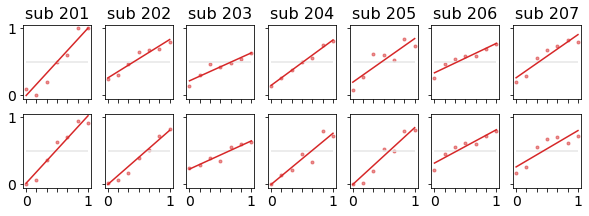

In [15]:
nrow, ncol = 2, 7
plt.subplots(nrows=nrow, ncols=ncol, figsize=(10, 3), sharey = True)

for session in range(nrow):
    for i in range(len(subID_select)):
        ax = plt.subplot(nrow, ncol, session * ncol + i + 1)
        ax.set_xlim(-0.05, 1.05)
        ax.set_ylim(-0.05, 1.05)

        # try:
        if session == 0:
            df_rate = df_rating_test_select
            df_curve = df_curve_test_select
            
        else:
            df_rate = df_rating_retest_select
            df_curve = df_curve_retest_select
            
        xfit = (df_rate.loc[df_rate['subID'] == subID_select[i], 'chargeSpeeds'] - 1.5)/7.5  #(180 - df_rate.loc[df_rate['subID'] == subID_select[i], 'subtlety'].values) / 180
        yfit = df_rate.loc[df_rate['subID'] == subID_select[i], 'responses']['mean'].values / 100
        yerr = df_rate.loc[df_rate['subID'] == subID_select[i], 'responses']['std'].values / 100
        
        slope = df_curve.loc[df_curve['subID'] == subID_select[i], 'slope'].values
        intercept = df_curve.loc[df_curve['subID'] == subID_select[i], 'intercept'].values
            
        x = np.array(xfit)
        y = np.array(yfit)
        
        # Plot behavioral dots
        ax.plot(x, y, '.', color='tab:red', alpha=0.5)
#       
        x_values = np.linspace(np.nanmin(x), np.nanmax(x), 100)
        y_values = linear(x_values, slope, intercept)

        ax.hlines(0.5,0,1,color = [.9,.9,.9]) 
        
        # Plot the curves
        ax.plot(x_values, y_values, '-', color='tab:red')
        ax.set_xticks(np.linspace(0,1,7))
        ax.set_xticklabels([0, '','','','','',  1])
        ax.set_yticks([0, 1])
        if session == 0:
            ax.set_title(f'sub {sub_title[i]}', size = 'medium')
            ax.tick_params(labelbottom=False)
            
plt.subplots_adjust(wspace=0.2, hspace=0.2)
plt.savefig('../../results/playfight/sample_subs_single_sub_plot_pf_linear.png',bbox_inches='tight',dpi=300)
plt.show()

# all subs

In [17]:
session = 0

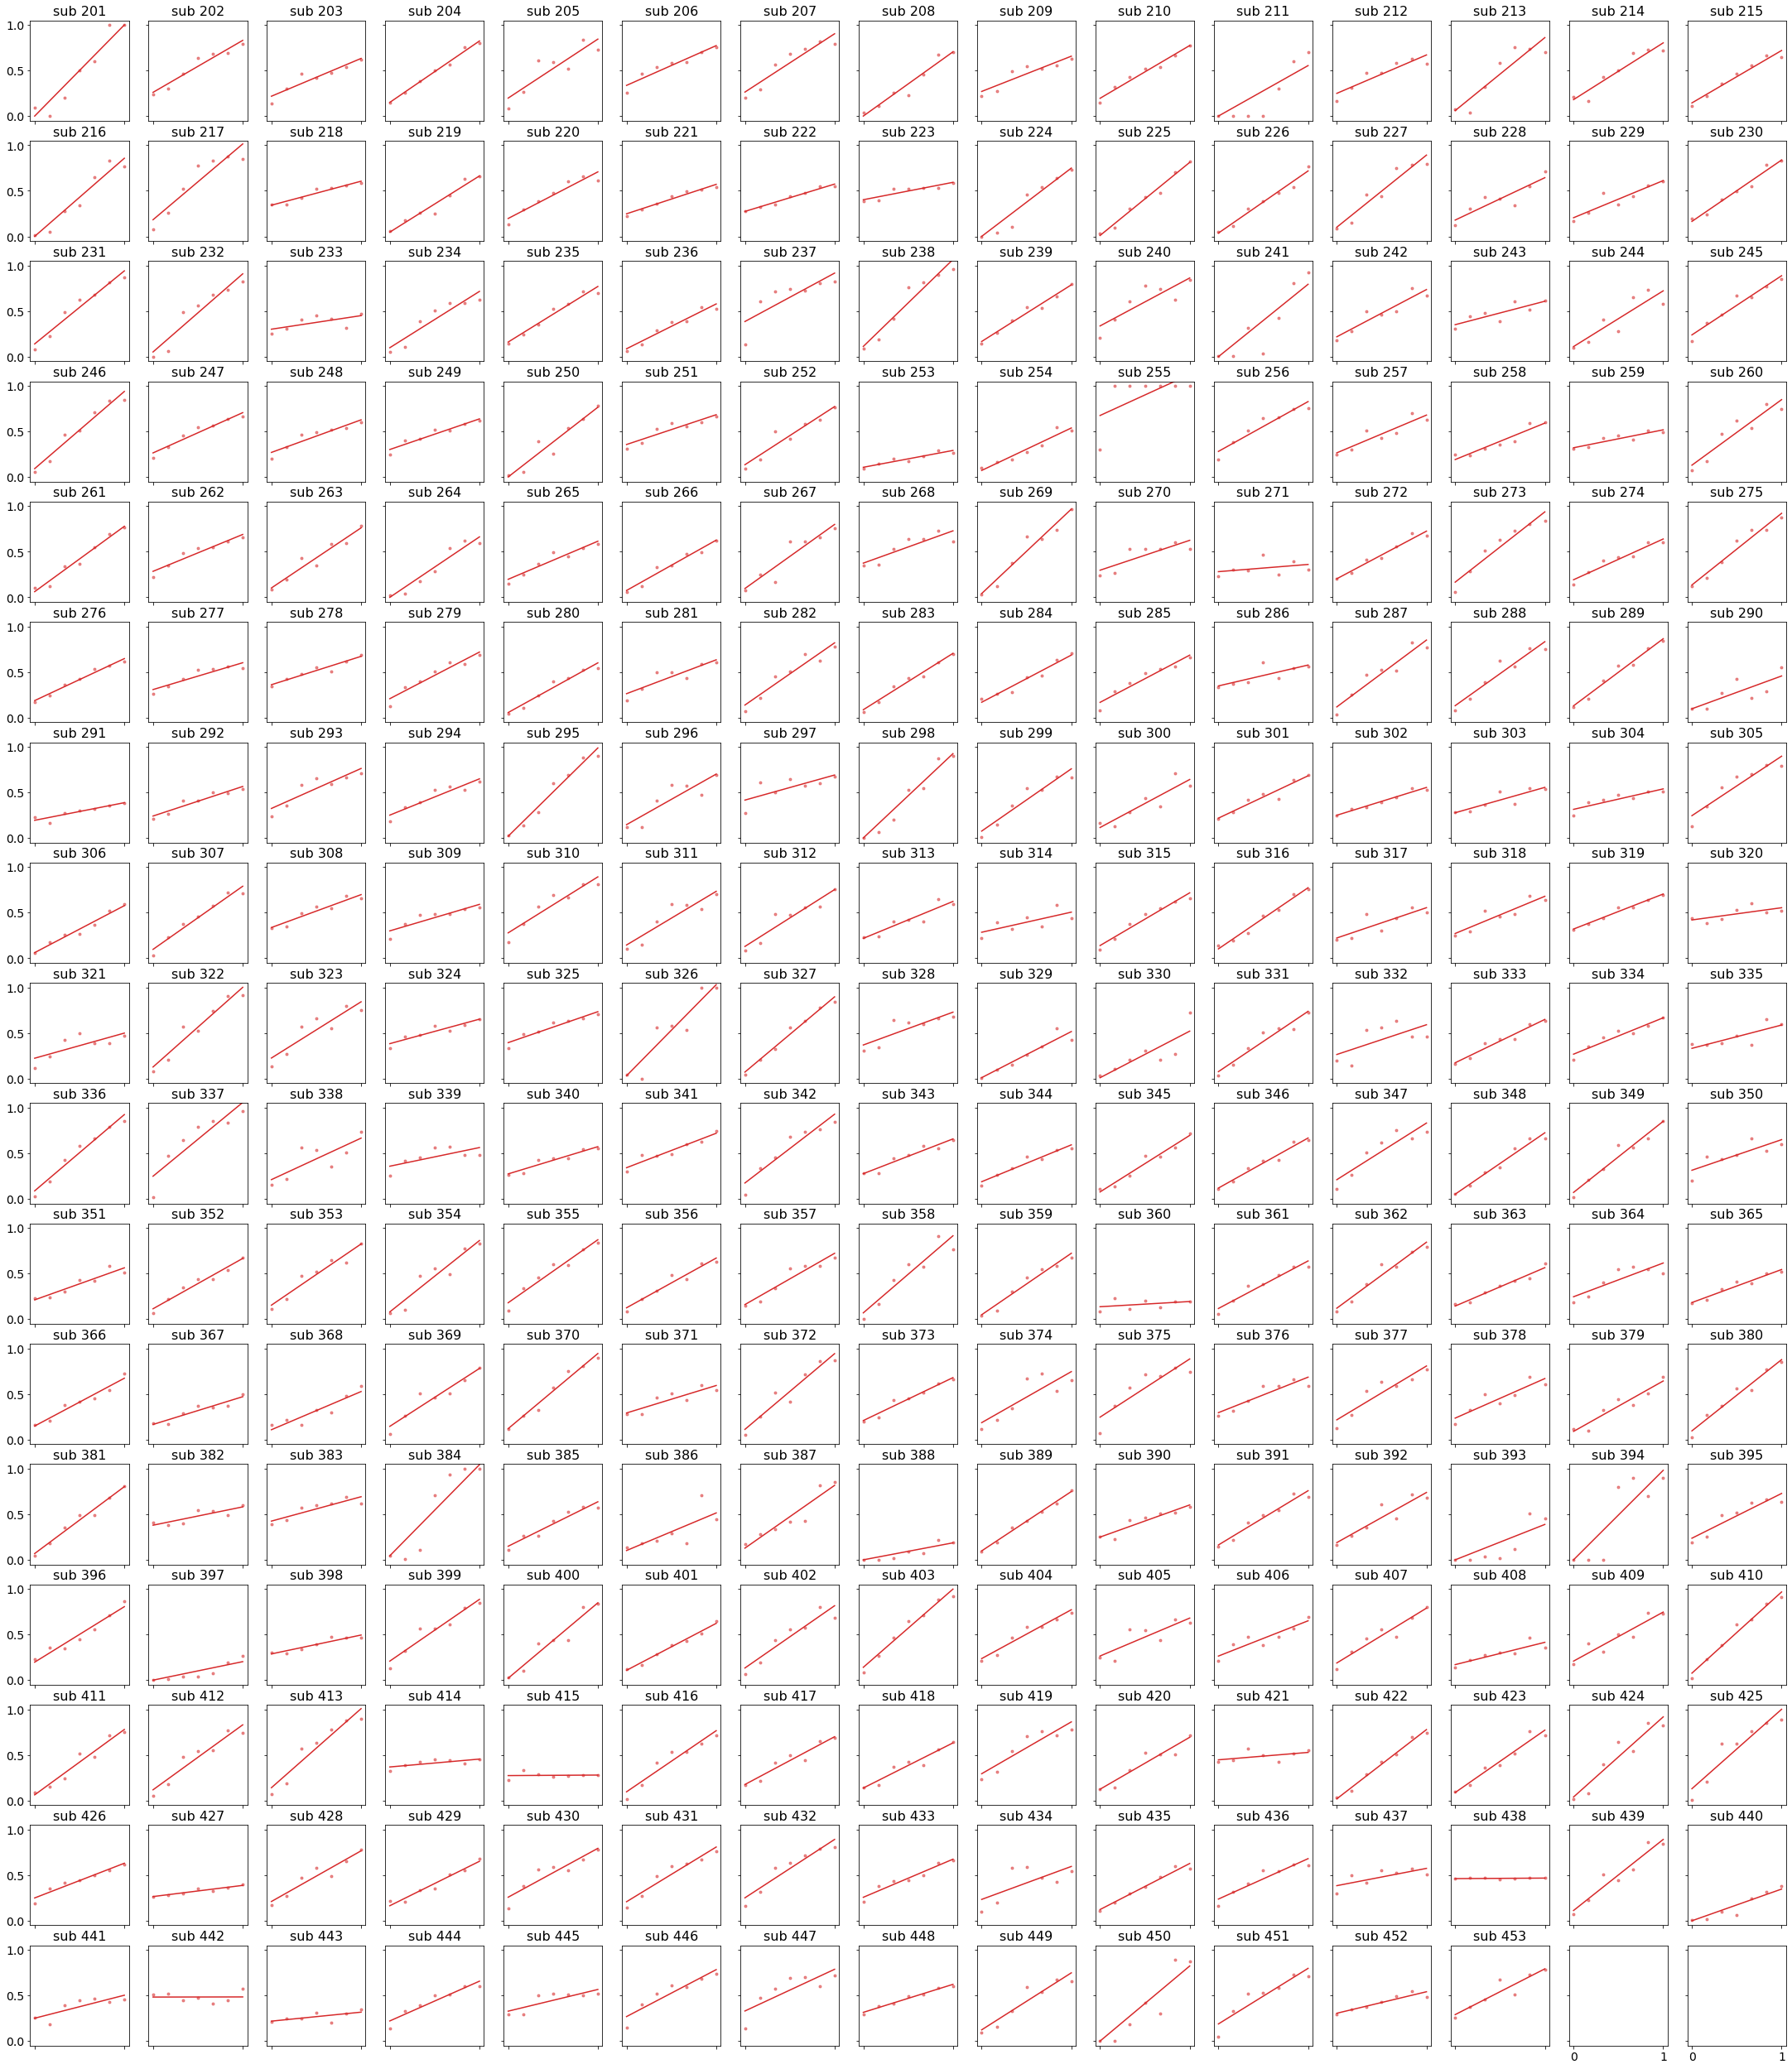

In [18]:
nrow, ncol = 17,15
fig,axs = plt.subplots(nrows=nrow, ncols=ncol, figsize=(38, 45), sharey = True,sharex=True)

for i in range(len(intersecting_subs)):
    
    row = int(np.floor(i/ncol))
    col = i%ncol
    ax = axs[row,col]
    
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)

    # try:
    if session == 0:
        df_rate = df_group_test
        df_curve = df_curve_test
        
    else:
        df_rate = df_group_retest
        df_curve = df_curve_retest
        
    xfit = (df_rate.loc[df_rate['subID'] == intersecting_subs[i], 'chargeSpeeds'] - 1.5)/7.5  #(180 - df_rate.loc[df_rate['subID'] == subID_select[i], 'subtlety'].values) / 180
    yfit = df_rate.loc[df_rate['subID'] == intersecting_subs[i], 'responses']['mean'].values / 100
    yerr = df_rate.loc[df_rate['subID'] == intersecting_subs[i], 'responses']['std'].values / 100
    
    slope = df_curve.loc[df_curve['subID'] == intersecting_subs[i], 'slope'].values
    intercept = df_curve.loc[df_curve['subID'] == intersecting_subs[i], 'intercept'].values
        
    x = np.array(xfit)
    y = np.array(yfit)
    
    # Plot behavioral dots
    ax.plot(x, y, '.', color='tab:red', alpha=0.5)
    
    x_values = np.linspace(np.nanmin(x), np.nanmax(x), 100)
    y_values = linear(x_values, slope, intercept)

    # Plot the curves
    ax.plot(x_values, y_values, '-', color='tab:red')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, .5,1])
    if session == 0:
        ax.set_title(f'sub {201+i}', size = 'medium')
        ax.tick_params(labelbottom=False)

plt.subplots_adjust(wspace=0.2, hspace=0.2)
plt.savefig('../../results/playfight/all_subs_single_sub_plot_fight_linear_ses1.png',bbox_inches='tight',dpi=300)

# [26003, 26005, 26329, 26009, 26192, 26113, 26168]

In [19]:
session=1

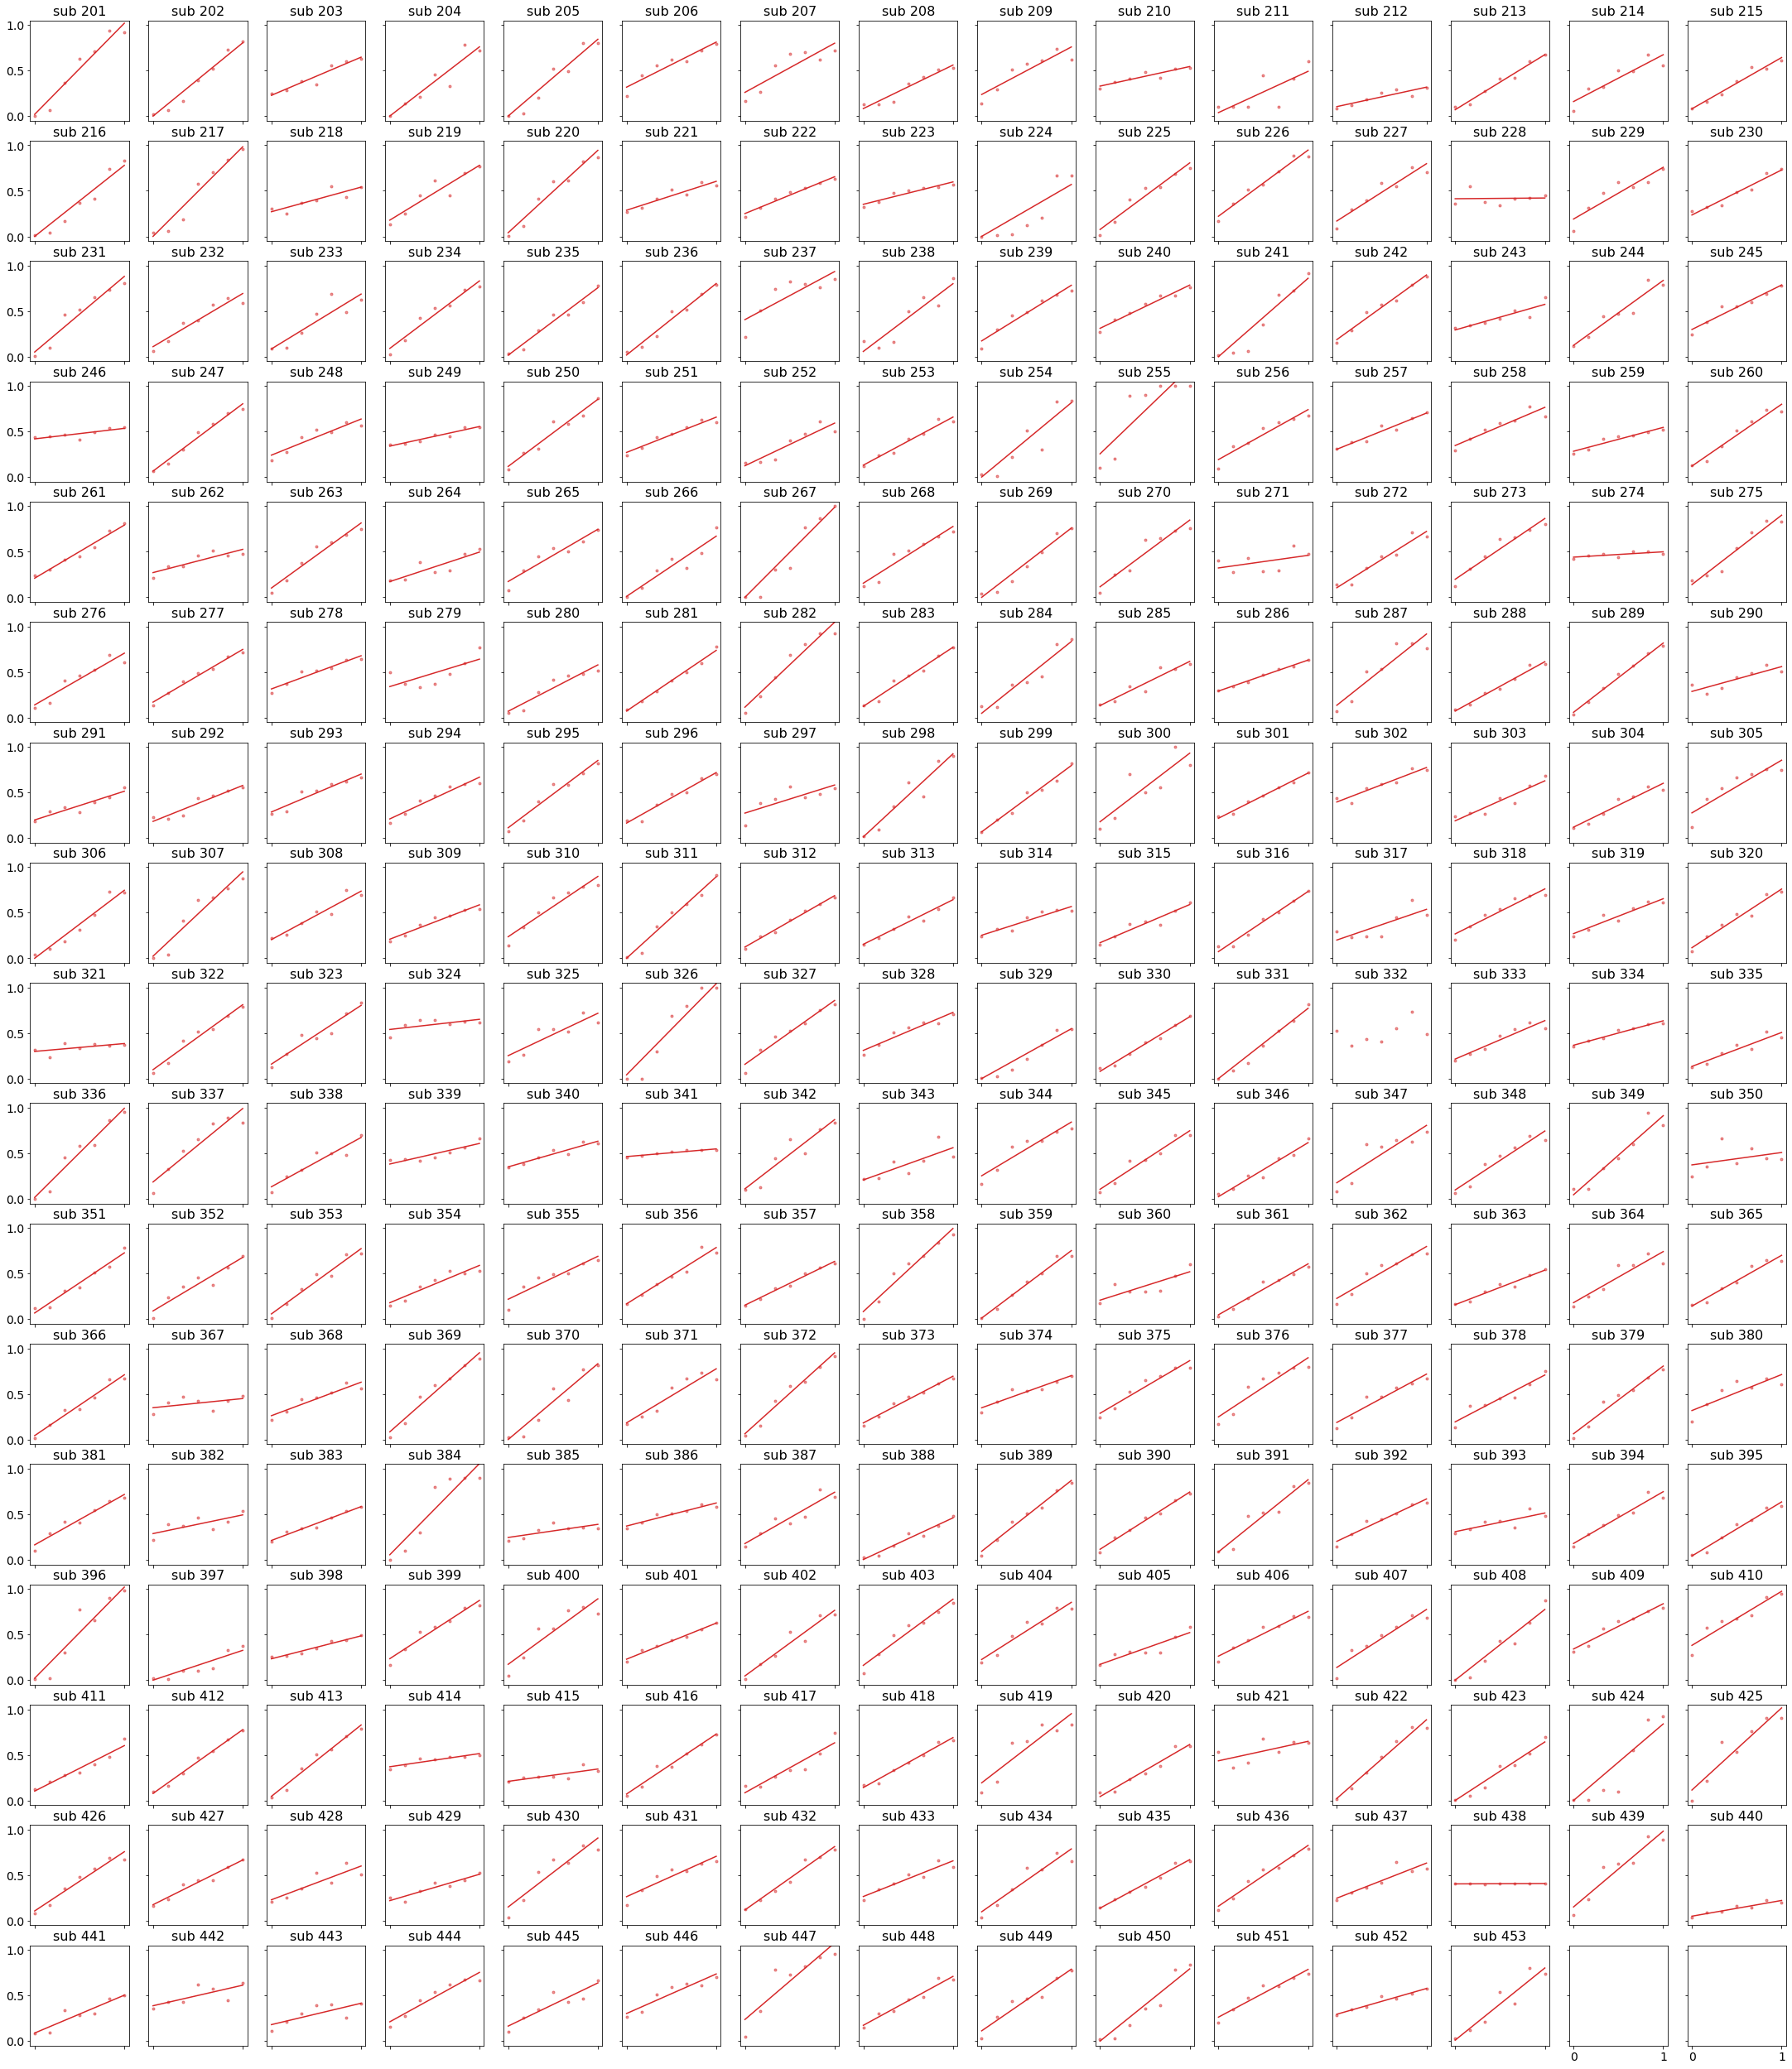

In [20]:
nrow, ncol = 17,15
fig,axs = plt.subplots(nrows=nrow, ncols=ncol, figsize=(38, 45), sharey = True,sharex=True)

for i in range(len(intersecting_subs)):
    row = int(np.floor(i/ncol))
    col = i%ncol
    ax = axs[row,col]
    
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)

    if session == 0:
        df_rate = df_group_test
        df_curve = df_curve_test
        
    else:
        df_rate = df_group_retest
        df_curve = df_curve_retest
        
    xfit = (df_rate.loc[df_rate['subID'] == intersecting_subs[i], 'chargeSpeeds'] - 1.5)/7.5  #(180 - df_rate.loc[df_rate['subID'] == subID_select[i], 'subtlety'].values) / 180
    yfit = df_rate.loc[df_rate['subID'] == intersecting_subs[i], 'responses']['mean'].values / 100
    yerr = df_rate.loc[df_rate['subID'] == intersecting_subs[i], 'responses']['std'].values / 100
    
    slope = df_curve.loc[df_curve['subID'] == intersecting_subs[i], 'slope'].values
    intercept = df_curve.loc[df_curve['subID'] == intersecting_subs[i], 'intercept'].values
        
    x = np.array(xfit)
    y = np.array(yfit)
    
    # Plot behavioral dots
    ax.plot(x, y, '.', color='tab:red', alpha=0.5)
    
    x_values = np.linspace(np.nanmin(x), np.nanmax(x), 100)
    y_values = linear(x_values, slope, intercept)

    # Plot the curves
    ax.plot(x_values, y_values, '-', color='tab:red')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, .5,1])
    if session == 1:
        ax.set_title(f'sub {201+i}', size = 'medium')
        ax.tick_params(labelbottom=False)

plt.subplots_adjust(wspace=0.2, hspace=0.2)
plt.savefig('../../results/playfight/all_subs_single_sub_plot_fight_linear_ses2.png',bbox_inches='tight',dpi=300)